In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [61]:
df = pd.read_csv("porter_excel_uncleaned.csv")

In [62]:
df.head()

,market_id,created_at_date,created_at_time,actual_delivery_date,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1,06-02-2015,22:24:17,06-02-2015,23:11:17,4,1,4,3441,4,557,1239,33,14,21,861
1,2,10-02-2015,21:49:25,10-02-2015,22:33:25,46,2,1,1900,1,1400,1400,1,2,2,690
2,2,16-02-2015,00:11:35,16-02-2015,01:06:35,36,3,4,4771,3,820,1604,8,6,18,289
3,1,12-02-2015,03:36:46,12-02-2015,04:35:46,38,1,1,1525,1,1525,1525,5,6,8,795
4,1,27-01-2015,02:12:36,27-01-2015,02:58:36,38,1,2,3620,2,1425,2195,5,5,7,205


In [8]:
df.shape

(175777, 16)

In [9]:
df.columns

Index(['market_id', 'created_at_date ', 'created_at_time ',
       'actual_delivery_date', 'actual_delivery_time',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration'],
      dtype='object')

In [10]:
### Clean column names

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df.columns

Index(['market_id', 'created_at_date', 'created_at_time',
       'actual_delivery_date', 'actual_delivery_time',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype 
---  ------                                        --------------   ----- 
 0   market_id                                     175777 non-null  int64 
 1   created_at_date                               175777 non-null  object
 2   created_at_time                               175777 non-null  object
 3   actual_delivery_date                          175777 non-null  object
 4   actual_delivery_time                          175777 non-null  object
 5   store_primary_category                        175777 non-null  int64 
 6   order_protocol                                175777 non-null  int64 
 7   total_items                                   175777 non-null  int64 
 8   subtotal                                      175777 non-null  int64 
 9   num_distinct_items                            175777 non-nu

In [15]:
df.describe()


,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
count,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000
mean,2.743726,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240
std,1.330963,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798
min,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000
25%,2.000000,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000
50%,2.000000,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000
75%,4.000000,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000
max,6.000000,72.000000,7.000000,411.000000,26800.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2088.000000


In [ ]:
####Check missing values

In [16]:
df.isnull().sum()

market_id                                       0
created_at_date                                 0
created_at_time                                 0
actual_delivery_date                            0
actual_delivery_time                            0
store_primary_category                          0
order_protocol                                  0
total_items                                     0
subtotal                                        0
num_distinct_items                              0
min_item_price                                  0
max_item_price                                  0
total_onshift_dashers                           0
total_busy_dashers                              0
total_outstanding_orders                        0
estimated_store_to_consumer_driving_duration    0
dtype: int64

In [17]:
#### Check duplicates

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates()

In [ ]:
####Convert dates

In [20]:
df['created_at_date'] = pd.to_datetime(
    df['created_at_date'],
    errors='coerce'
)

df['actual_delivery_date'] = pd.to_datetime(
    df['actual_delivery_date'],
    errors='coerce'
)

In [ ]:
#### Convert time

In [21]:
df['created_at_time'] = pd.to_datetime(
    df['created_at_time'],
    errors='coerce'
).dt.time

C:\Users\gokul\AppData\Local\Temp\ipykernel_26972\1653385246.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at_time'] = pd.to_datetime(


In [22]:
df['actual_delivery_time'] = pd.to_datetime(
    df['actual_delivery_time'],
    errors='coerce'
).dt.time

C:\Users\gokul\AppData\Local\Temp\ipykernel_26972\2518712922.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['actual_delivery_time'] = pd.to_datetime(


In [23]:
### Check negative values

In [24]:
numeric_columns = [
    'total_items',
    'subtotal',
    'num_distinct_items',
    'min_item_price',
    'max_item_price',
    'total_onshift_dashers',
    'total_busy_dashers',
    'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration'
]

for col in numeric_columns:
    print(col, (df[col] < 0).sum())

total_items 0
subtotal 0
num_distinct_items 0
min_item_price 12
max_item_price 0
total_onshift_dashers 21
total_busy_dashers 21
total_outstanding_orders 41
estimated_store_to_consumer_driving_duration 0


In [ ]:
### Basic KPIs

In [25]:
total_orders = len(df)

total_items = df['total_items'].sum()

total_revenue = df['subtotal'].sum()

average_order_value = df['subtotal'].mean()

average_items = df['total_items'].mean()

average_delivery_duration = (
    df['estimated_store_to_consumer_driving_duration'].mean()
)

print("Total Orders:", total_orders)
print("Total Items:", total_items)
print("Total Revenue:", total_revenue)
print("Average Order Value:", average_order_value)
print("Average Items:", average_items)
print("Average Delivery Duration:", average_delivery_duration)

Total Orders: 175777
Total Items: 563361
Total Revenue: 474090106
Average Order Value: 2697.1111465094978
Average Items: 3.204975622521718
Average Delivery Duration: 546.0772399119338


In [26]:
####Category analysis

In [27]:
category_analysis = df.groupby(
    'store_primary_category'
).agg(
    total_orders=('store_primary_category', 'size'),
    total_items=('total_items', 'sum'),
    revenue=('subtotal', 'sum'),
    average_order_value=('subtotal', 'mean')
).sort_values(
    'revenue',
    ascending=False
)

category_analysis.head(10)

,total_orders,total_items,revenue,average_order_value
store_primary_category,,,,
4,18183,50116,48291649,2655.868064
55,15745,40470,47620494,3024.483582
46,15586,49170,36142560,2318.911844
39,8232,32655,28084696,3411.649174
38,6733,20079,25408958,3773.794445
20,8563,29252,24559102,2868.048815
13,9915,31959,22035442,2222.434897
24,8085,22933,20010988,2475.075819
68,6235,22674,19592793,3142.388613


In [28]:
### Category visualization

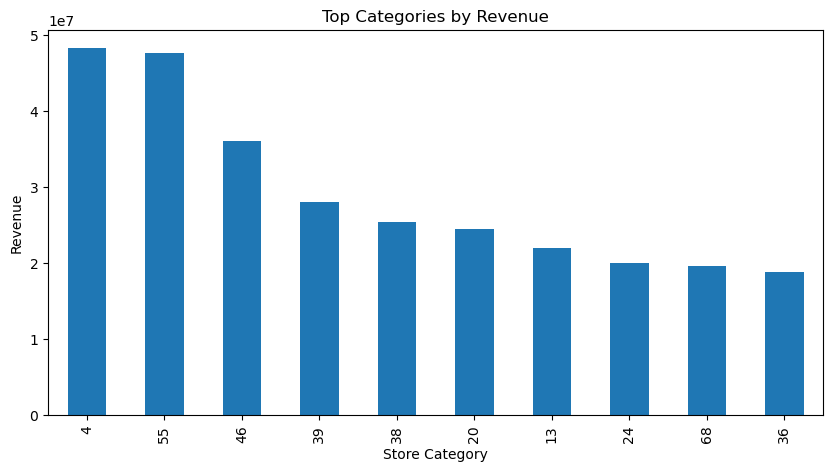

In [29]:
category_analysis.head(10)['revenue'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Categories by Revenue')
plt.xlabel('Store Category')
plt.ylabel('Revenue')
plt.show()

In [ ]:
### Order protocol analysis

In [30]:
protocol_analysis = df.groupby(
    'order_protocol'
).agg(
    total_orders=('order_protocol', 'size'),
    revenue=('subtotal', 'sum'),
    average_order_value=('subtotal', 'mean')
).sort_values(
    'total_orders',
    ascending=False
)

protocol_analysis

,total_orders,revenue,average_order_value
order_protocol,,,
1,48404,135397696,2797.241881
3,47125,136936657,2905.817655
5,41415,112732018,2722.009369
2,20890,56852101,2721.498372
4,17246,30731141,1781.928621
6,678,1383228,2040.159292
7,19,57265,3013.947368


In [ ]:
####Protocol visualization

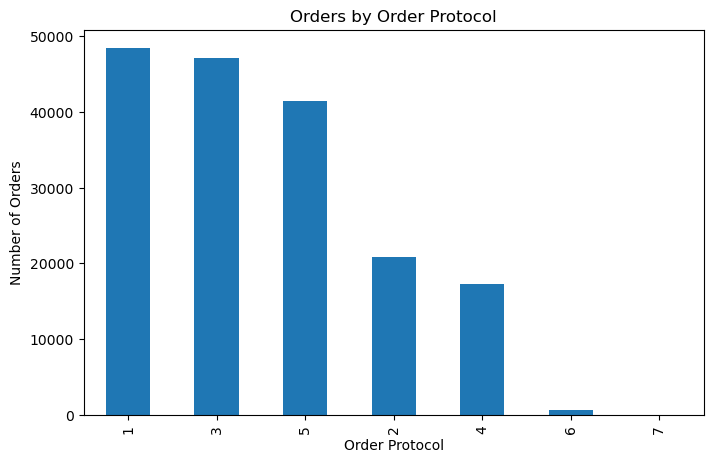

In [31]:
protocol_analysis['total_orders'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Orders by Order Protocol')
plt.xlabel('Order Protocol')
plt.ylabel('Number of Orders')
plt.show()

In [ ]:
#### Market analysis

In [32]:
market_analysis = df.groupby(
    'market_id'
).agg(
    total_orders=('market_id', 'size'),
    revenue=('subtotal', 'sum'),
    average_order_value=('subtotal', 'mean')
).sort_values(
    'revenue',
    ascending=False
)

market_analysis

,total_orders,revenue,average_order_value
market_id,,,
2,53469,140559597,2628.805420
4,46222,134147634,2902.246419
1,37115,101859994,2744.442786
3,21075,54207454,2572.121186
5,17258,41620983,2411.692143
6,638,1694444,2655.868339


In [ ]:
### Monthly analysis
## Create year and month:

In [33]:
df['year'] = df['created_at_date'].dt.year
df['month'] = df['created_at_date'].dt.month
df['month_name'] = df['created_at_date'].dt.month_name()

In [34]:
monthly_analysis = df.groupby(
    ['year', 'month']
).agg(
    total_orders=('subtotal', 'size'),
    revenue=('subtotal', 'sum')
).reset_index()

monthly_analysis

,year,month,total_orders,revenue
0,2015.0,1.0,6941,19608840
1,2015.0,2.0,5958,16664905
2,2015.0,3.0,5636,14787546
3,2015.0,4.0,5429,14191359
4,2015.0,5.0,6032,15622918
5,2015.0,6.0,6302,16091560
6,2015.0,7.0,8082,22444963
7,2015.0,8.0,7855,21594487
8,2015.0,9.0,6346,17093003
9,2015.0,10.0,5400,13843935


In [ ]:
#### Monthly orders graph

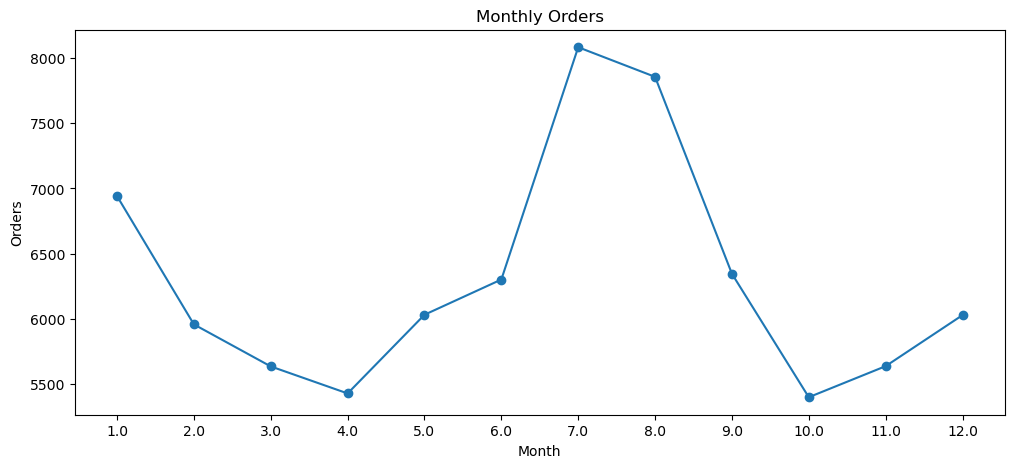

In [35]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis['month'].astype(str),
    monthly_analysis['total_orders'],
    marker='o'
)

plt.title('Monthly Orders')
plt.xlabel('Month')
plt.ylabel('Orders')

plt.show()

In [ ]:
#### Monthly revenue graph

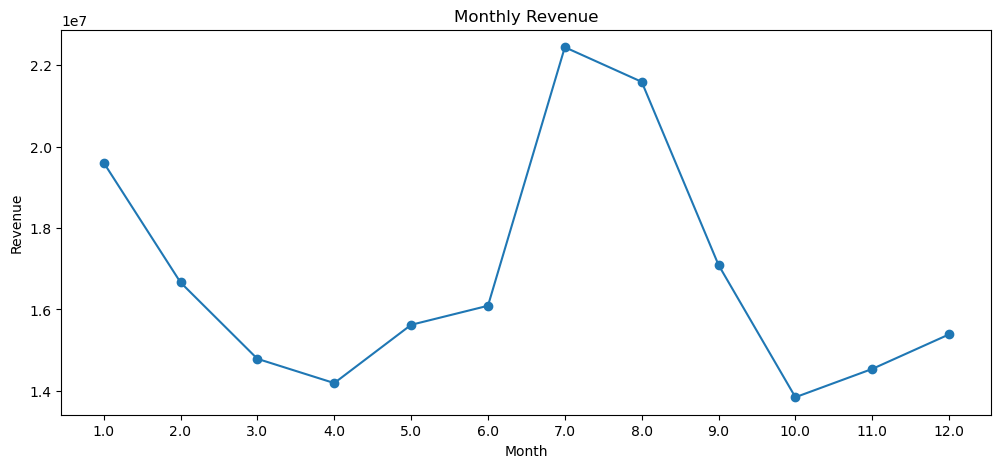

In [36]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis['month'].astype(str),
    monthly_analysis['revenue'],
    marker='o'
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [ ]:
####Delivery duration analysis

In [37]:
delivery_analysis = df.groupby(
    'store_primary_category'
).agg(
    orders=('store_primary_category', 'size'),
    average_delivery_duration=(
        'estimated_store_to_consumer_driving_duration',
        'mean'
    )
).sort_values(
    'average_delivery_duration',
    ascending=False
)

delivery_analysis.head(10)

,orders,average_delivery_duration
store_primary_category,,
3,1,791.000000
62,57,631.350877
17,243,616.654321
44,92,608.217391
35,1451,603.696761
52,625,601.342400
40,1693,596.149439
37,55,591.727273
65,1032,590.876938


In [38]:
#### Delivery duration distribution

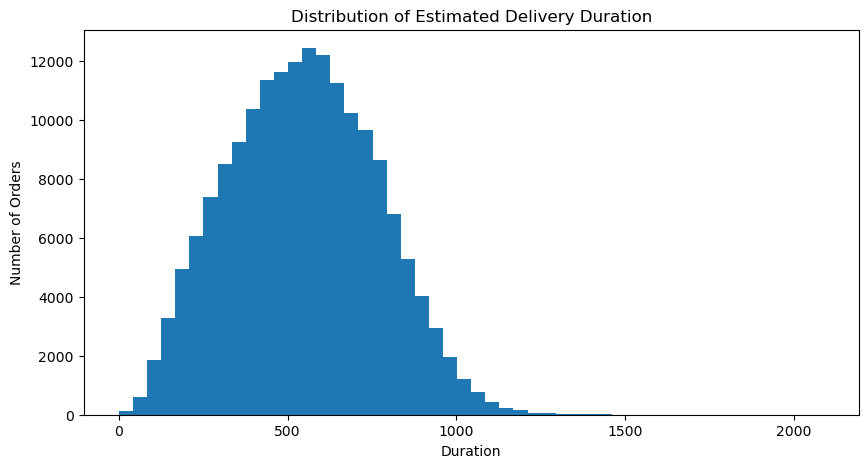

In [39]:
plt.figure(figsize=(10,5))

plt.hist(
    df['estimated_store_to_consumer_driving_duration'].dropna(),
    bins=50
)

plt.title('Distribution of Estimated Delivery Duration')
plt.xlabel('Duration')
plt.ylabel('Number of Orders')

plt.show()

In [ ]:
#### Order value distribution

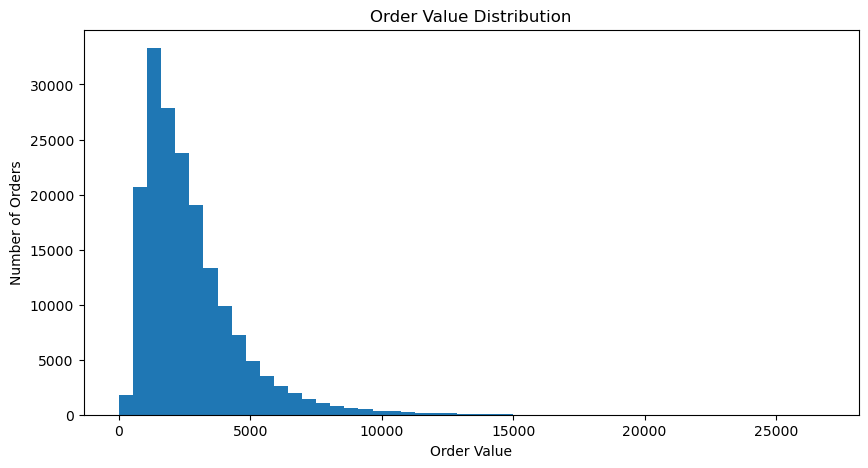

In [40]:
plt.figure(figsize=(10,5))

plt.hist(
    df['subtotal'].dropna(),
    bins=50
)

plt.title('Order Value Distribution')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')

plt.show()

In [ ]:
#### Boxplot for order value

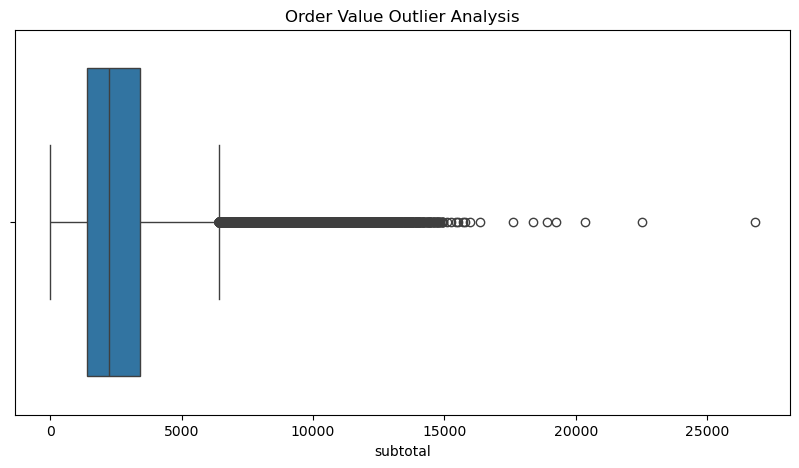

In [41]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['subtotal']
)

plt.title('Order Value Outlier Analysis')
plt.show()

In [ ]:
#### Correlation analysis

In [42]:
correlation_columns = [
    'total_items',
    'subtotal',
    'num_distinct_items',
    'min_item_price',
    'max_item_price',
    'total_onshift_dashers',
    'total_busy_dashers',
    'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration'
]

correlation = df[correlation_columns].corr()

correlation

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
total_items,1.000000,0.554951,0.758339,-0.389471,-0.053749,0.032087,0.029084,0.034818,0.006589
subtotal,0.554951,1.000000,0.680842,0.038778,0.509787,0.131239,0.126150,0.130481,0.038156
num_distinct_items,0.758339,0.680842,1.000000,-0.446503,0.047113,0.065793,0.060508,0.067730,0.024535
min_item_price,-0.389471,0.038778,-0.446503,1.000000,0.541522,0.042655,0.044311,0.041478,0.004464
max_item_price,-0.053749,0.509787,0.047113,0.541522,1.000000,0.133786,0.131835,0.131364,0.029366
total_onshift_dashers,0.032087,0.131239,0.065793,0.042655,0.133786,1.000000,0.943725,0.936121,0.045269
total_busy_dashers,0.029084,0.126150,0.060508,0.044311,0.131835,0.943725,1.000000,0.932826,0.043948
total_outstanding_orders,0.034818,0.130481,0.067730,0.041478,0.131364,0.936121,0.932826,1.000000,0.039147
estimated_store_to_consumer_driving_duration,0.006589,0.038156,0.024535,0.004464,0.029366,0.045269,0.043948,0.039147,1.000000


In [ ]:
#### Correlation heatmap

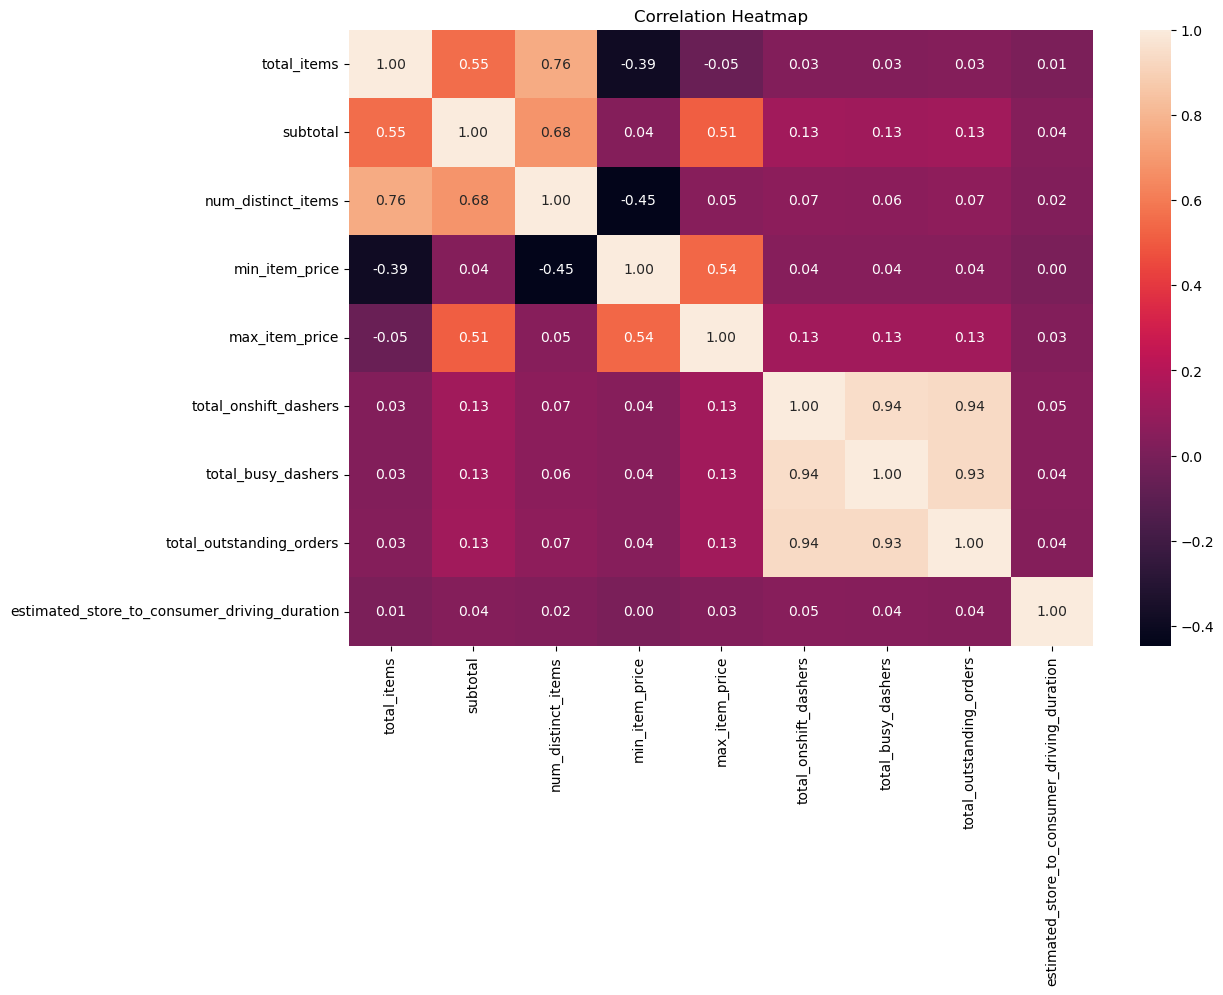

In [43]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
### Dasher analysis

In [44]:
dasher_analysis = df[[
    'total_onshift_dashers',
    'total_busy_dashers',
    'total_outstanding_orders'
]].mean()

dasher_analysis

total_onshift_dashers       44.918664
total_busy_dashers          41.861381
total_outstanding_orders    58.230115
dtype: float64

In [ ]:
#### Busy dasher percentage

In [45]:
busy_dasher_percentage = (
    df['total_busy_dashers'].sum() /
    df['total_onshift_dashers'].sum()
) * 100

print(
    "Busy Dasher Percentage:",
    round(busy_dasher_percentage, 2),
    "%"
)

Busy Dasher Percentage: 93.19 %


In [ ]:
### Outstanding orders analysis

In [46]:
df[['total_outstanding_orders']].describe()

,total_outstanding_orders
count,175777.000000
mean,58.230115
std,52.731043
min,-6.000000
25%,17.000000
50%,41.000000
75%,85.000000
max,285.000000


In [ ]:
#### Outstanding orders graph

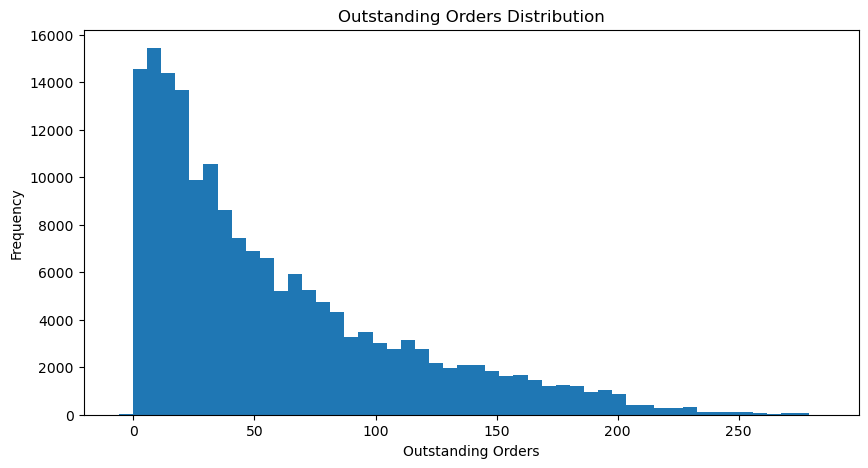

In [47]:
plt.figure(figsize=(10,5))

plt.hist(
    df['total_outstanding_orders'].dropna(),
    bins=50
)

plt.title('Outstanding Orders Distribution')
plt.xlabel('Outstanding Orders')
plt.ylabel('Frequency')

plt.show()

In [ ]:
### Items vs revenue

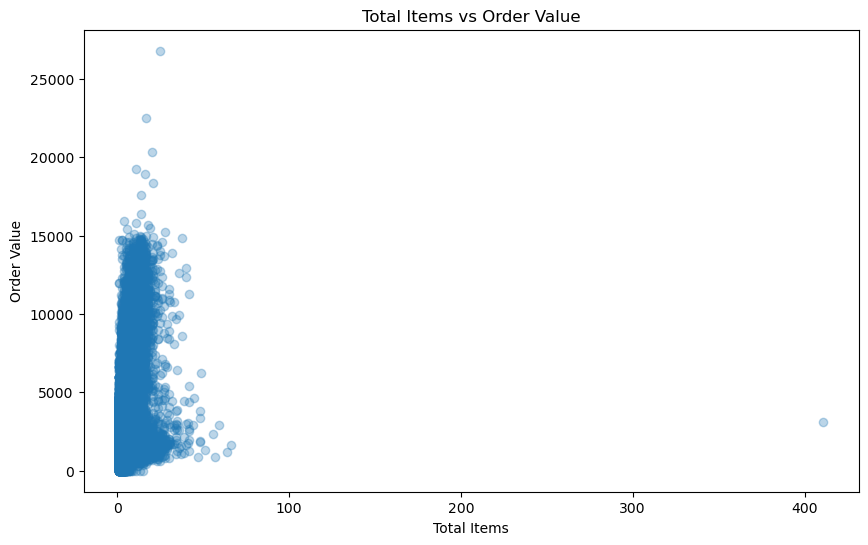

In [48]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['total_items'],
    df['subtotal'],
    alpha=0.3
)

plt.title('Total Items vs Order Value')
plt.xlabel('Total Items')
plt.ylabel('Order Value')

plt.show()

In [ ]:
#### Delivery duration vs outstanding orders

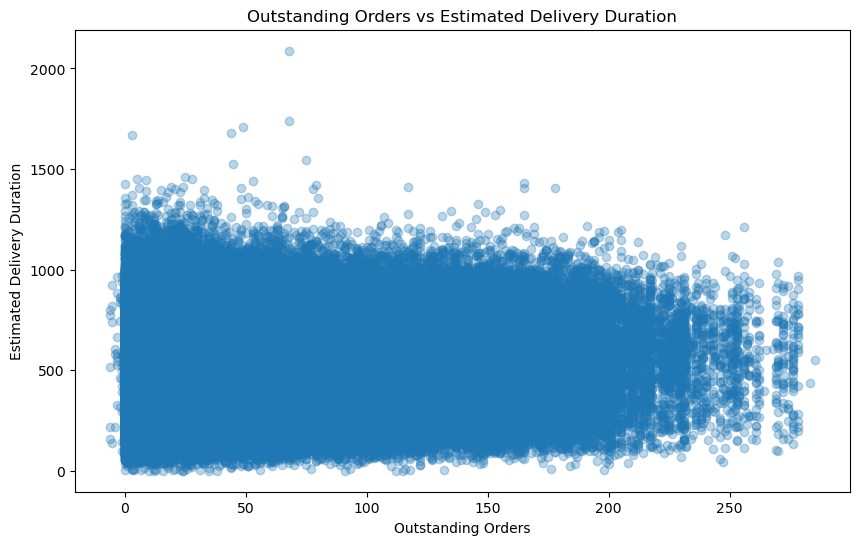

In [49]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['total_outstanding_orders'],
    df['estimated_store_to_consumer_driving_duration'],
    alpha=0.3
)

plt.title(
    'Outstanding Orders vs Estimated Delivery Duration'
)

plt.xlabel('Outstanding Orders')
plt.ylabel('Estimated Delivery Duration')

plt.show()

In [ ]:
#### Create delivery groups

In [50]:
def delivery_group(x):
    if x < 15:
        return 'Short'
    elif x < 30:
        return 'Medium'
    elif x < 45:
        return 'Long'
    else:
        return 'Very Long'

df['delivery_group'] = (
    df['estimated_store_to_consumer_driving_duration']
    .apply(delivery_group)
)

In [51]:
df['delivery_group'].value_counts()

delivery_group
Very Long    175630
Long             84
Short            32
Medium           31
Name: count, dtype: int64

In [ ]:
#### Create order-value groups

In [52]:
def order_value_group(x):
    if x < 200:
        return 'Low Value'
    elif x < 500:
        return 'Medium Value'
    elif x < 1000:
        return 'High Value'
    else:
        return 'Very High Value'

df['order_value_group'] = (
    df['subtotal']
    .apply(order_value_group)
)

In [53]:
df['order_value_group'].value_counts()

order_value_group
Very High Value    156813
High Value          17579
Medium Value         1192
Low Value             193
Name: count, dtype: int64

In [ ]:
### Top 10 markets

In [54]:
market_analysis.head(10)

,total_orders,revenue,average_order_value
market_id,,,
2,53469,140559597,2628.805420
4,46222,134147634,2902.246419
1,37115,101859994,2744.442786
3,21075,54207454,2572.121186
5,17258,41620983,2411.692143
6,638,1694444,2655.868339


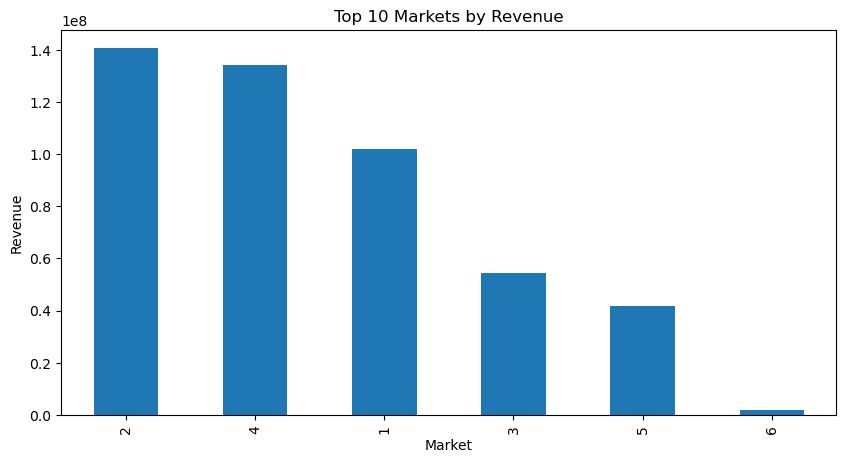

In [55]:
market_analysis.head(10)['revenue'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Markets by Revenue')
plt.xlabel('Market')
plt.ylabel('Revenue')

plt.show()

In [56]:
### Top 10 highest orders

In [58]:
df.nlargest(
    10,
    'subtotal'
)[[
    'market_id',
    'store_primary_category',
    'total_items',
    'subtotal',
    'order_protocol'
]]

,market_id,store_primary_category,total_items,subtotal,order_protocol
167615,1,72,25,26800,5
85571,1,38,17,22500,5
47088,1,55,20,20350,5
64746,4,72,11,19250,1
152562,4,34,16,18920,3
7992,1,57,21,18370,1
157582,4,47,14,17600,5
48303,4,59,14,16350,5
161403,2,61,4,15960,2
63130,6,34,11,15800,5


In [ ]:
### Save

In [59]:
df.to_csv(
    'porter_cleaned_for_powerbi.csv',
    index=False
)